In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [27]:
from copy import deepcopy
from functools import partial

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from sklearn.metrics import auc
from tqdm import tqdm
from scipy.stats import spearmanr

from rebinding.efflux_model_collection import washout_zero_bound_extra_compartment
from rebinding.fig_utils import defaultStyle, save_fig
from rebinding.pd_expt import pd_data_processing, plot_cell_growth, plot_gr_curves

defaultStyle(fs=14)

# Load data

In [5]:
default_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.003), np.log10(30), 9)])
alisertib_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.01), np.log10(100), 9)])
ispinesib_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.001), np.log10(5), 9)])
topotecan_conc = np.concatenate([[1e-4], np.logspace(np.log10(0.01), np.log10(30), 9)])
len(default_conc), len(alisertib_conc), len(ispinesib_conc)

data_no_wash = pd.concat(
    [
        pd_data_processing(
            "../data/BYL273/BYL273-1/E549F4D7_summary_positions_EC.xlsx",
            cpds=["PTX", "DTX", "Alisertib"],
            concs=[
                default_conc,
                default_conc,
                alisertib_conc,
            ],
            plate_idx=1,
        ),
        pd_data_processing(
            "../data/BYL273/BYL273-3/435C4CAA_summary_positions_EC.xlsx",
            cpds=["Colchicine", "CA4", "Ispinesib"],
            concs=[
                default_conc,
                default_conc,
                ispinesib_conc,
            ],
            plate_idx=2,
        ),
        pd_data_processing(
            "../data/BYL273/BYL273-3/435C4CAA_summary_positions_EC.xlsx",
            cpds=["VB", "Topotecan", "Doxorubicin"],
            concs=[
                default_conc,
                topotecan_conc,
                topotecan_conc,
            ],
            plate_idx=3,
        ),
        pd_data_processing(
            "../data/BYL283/BYL283-1/411A7FE3_summary_positions_EC.xlsx",
            cpds=["PTX-2", "SN-38", "Ispinesib-2"],
            concs=[
                default_conc,
                default_conc,
                ispinesib_conc,
            ],
            plate_idx=4,
            drop_cpd=["PTX-2", "SN-38"],
        ),
    ]
).reset_index(drop=True)
data_wash = pd.concat(
    [
        pd_data_processing(
            "../data/BYL273/BYL273-2/838184F1_summary_positions_EC.xlsx",
            cpds=["PTX", "DTX", "Alisertib"],
            concs=[default_conc, default_conc, alisertib_conc],
            plate_idx=5,
        ),
        pd_data_processing(
            "../data/BYL273/BYL273-4/89C03840_summary_positions_EC.xlsx",
            cpds=["Colchicine", "CA4", "Ispinesib"],
            concs=[default_conc, default_conc, ispinesib_conc],
            plate_idx=6,
            # drop_cpd="Ispinesib"
        ),
        pd_data_processing(
            "../data/BYL273/BYL273-6/55691080_summary_positions_EC.xlsx",
            cpds=["VB", "Topotecan", "Doxorubicin"],
            concs=[
                default_conc,
                topotecan_conc,
                topotecan_conc,
            ],
            plate_idx=7,
        ),
        pd_data_processing(
            "../data/BYL283/BYL283-2/A24C5644_summary_positions_EC.xlsx",
            cpds=["PTX-2", "SN-38", "Ispinesib-2"],
            concs=[
                default_conc,
                default_conc,
                ispinesib_conc,
            ],
            plate_idx=8,
            drop_cpd=["PTX-2", "SN-38"],
        ),
    ]
).reset_index(drop=True)

# Filter data

In [6]:
data_no_wash["Wash"] = False
data_wash["Wash"] = True
data = pd.concat([data_no_wash, data_wash]).reset_index(drop=True)
data["lgc"] = data.c.apply(lambda x: np.log10(x * 1e4))
print(len(data), end="\t")
abspos_to_keep = data[
    (data.t == 0) & (data.confluency > 10) & (data.confluency < 30)
].abs_pos.tolist()
data.drop(data[np.logical_not(data.abs_pos.isin(abspos_to_keep))].index, inplace=True)
data.drop(data[(data.cpd == "Ispinesib") & (data.c > 0.5)].index, inplace=True)
len(data)

49600	

32581

# Normalization

In [7]:
def pd_data_normalize_t(data):
    data_init = (
        data[data.t == 0][["abs_pos", "confluency"]]
        .groupby(["abs_pos"])
        .mean()
        .reset_index()
    )
    data["confluency_init"] = data.apply(
        lambda df: data_init.loc[data_init.abs_pos == df.abs_pos, "confluency"].values[
            0
        ],
        axis=1,
    )
    data["confluency_norm"] = data.confluency / data.confluency_init
    data_ctrl = (
        data[data.c == 1e-4][["confluency_norm", "plate", "t"]]
        .groupby(["plate", "t"])
        .mean()
        .reset_index()
    )
    data["confluency_norm_ctrl"] = data.apply(
        lambda df: data_ctrl.loc[
            (data_ctrl.plate == df.plate) & (data_ctrl.t == df.t),
            "confluency_norm",
        ].values[0],
        axis=1,
    )
    data["gr"] = data.apply(
        lambda df: 2 ** (np.log(df.confluency_norm) / np.log(df.confluency_norm_ctrl))
        - 1,
        axis=1,
    )


def time_dependent_gr(data):
    abs_pos_list = data.abs_pos.unique()
    abs_pos_to_growth_rate = {}
    for abs_pos in abs_pos_list:
        curr_data = data[data.abs_pos == abs_pos]
        curr_conf_data = savgol_filter(curr_data.confluency.values, 7, 1)
        data.loc[data.abs_pos == abs_pos, "confluency_smooth"] = curr_conf_data
        g_t = np.concatenate(
            [
                [curr_conf_data[1] / curr_conf_data[0]],
                curr_conf_data[2:] / curr_conf_data[:-2],
                [curr_conf_data[-1] / curr_conf_data[-2]],
            ]
        )
        data.loc[data.abs_pos == abs_pos, "g_t"] = g_t


def normalize_gr(data):
    data_ctrl = (
        data[data.c == 1e-4][["g_t", "plate", "t"]]
        .groupby(["plate", "t"])
        .mean()
        .reset_index()
    )
    data["g_t_ctrl"] = data.apply(
        lambda df: data_ctrl.loc[
            (data_ctrl.plate == df.plate) & (data_ctrl.t == df.t),
            "g_t",
        ].values[0],
        axis=1,
    )
    data["gr_t"] = data.apply(
        lambda df: 2 ** (np.log(df.g_t) / np.log(df.g_t_ctrl)) - 1,
        axis=1,
    )


pd_data_normalize_t(data)
time_dependent_gr(data)
normalize_gr(data)

/tmp/ipykernel_25682/1632784019.py:29: RuntimeWarning: invalid value encountered in scalar divide
  lambda df: 2 ** (np.log(df.confluency_norm) / np.log(df.confluency_norm_ctrl))
/tmp/ipykernel_25682/1632784019.py:67: RuntimeWarning: overflow encountered in scalar power
  lambda df: 2 ** (np.log(df.g_t) / np.log(df.g_t_ctrl)) - 1,


# Plot

100%|██████████████████████████████████████████████| 3/3 [00:00<00:00,  4.68it/s]
/home/liboyan/Documents/Research/rebind/rebinding2025/code/rebinding/fig_utils.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure fig5-growth-curves


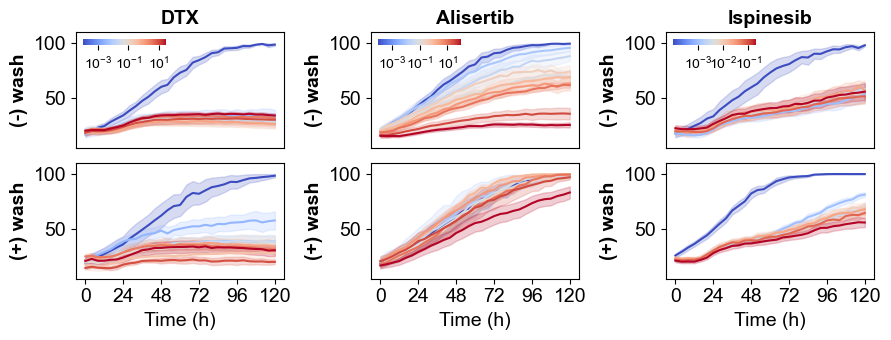

In [8]:
cpds = ["DTX", "Alisertib", "Ispinesib"]

_, axes = plt.subplots(2, 3, figsize=(9, 3.5))
plt.subplots_adjust(hspace=0.0, wspace=0.0)
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = axes[:, i]
    cbar_ticks = [1, 2, 3] if cpd == "Ispinesib" else [1, 3, 5]
    cbar_ticklabels = (
        [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
        if cpd == "Ispinesib"
        else [r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
    )
    plot_cell_growth(
        cpd, data, axes=curr_ax, cbar_ticks=cbar_ticks, cbar_ticklabels=cbar_ticklabels
    )
    for bx in curr_ax:
        bx.set_xlabel("")
        bx.set_ylabel("")
    curr_ax[0].set_title(cpd, fontsize=14, fontweight="bold")
    curr_ax[1].set_title("")
    for bx in curr_ax:
        """
        bx.tick_params(
            axis="x",
            which="both",
            bottom=False,
            labelbottom=False,
        )
        bx.tick_params(
            axis="y",
            which="both",
            left=False,
            labelleft=False,
        )
        """
        bx.set_xticks([24 * i for i in range(6)])
        bx.set_ylim([5, 110])
    curr_ax[0].set_ylabel("(-) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_ylabel("(+) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_xlabel("Time (h)", fontsize=14)
    curr_ax[0].tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )
save_fig(f"fig5-growth-curves", fmt="png", dpi=300)

100%|██████████████████████████████████████████████| 6/6 [00:01<00:00,  4.43it/s]
/home/liboyan/Documents/Research/rebind/rebinding2025/code/rebinding/fig_utils.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saving figure figEx7-growth-curves


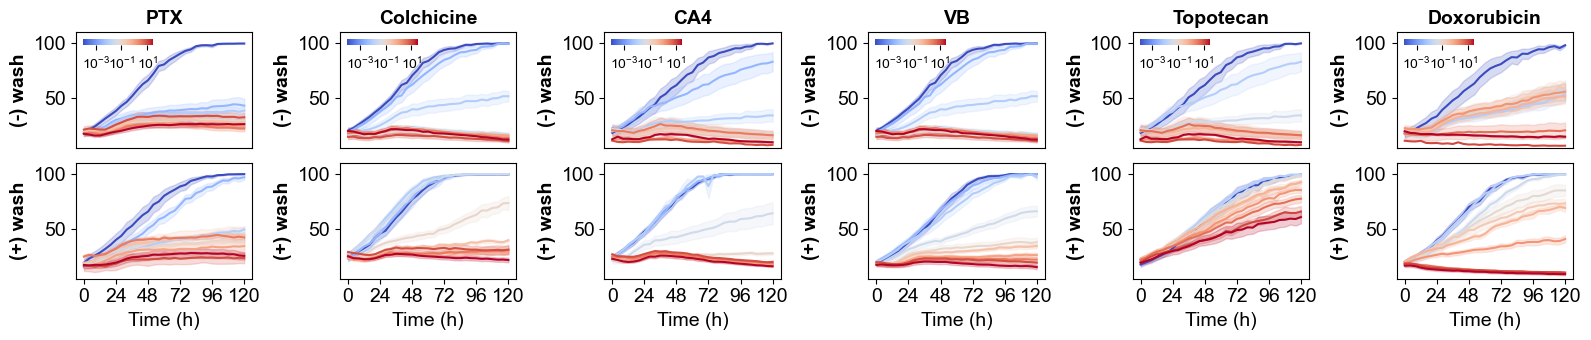

In [9]:
cpds = ["PTX", "Colchicine", "CA4", "VB", "Topotecan", "Doxorubicin"]

_, axes = plt.subplots(2, 6, figsize=(16, 3.5))
plt.subplots_adjust(hspace=0.0, wspace=0.0)
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = axes[:, i]
    cbar_ticks = [1, 2, 3] if cpd == "Ispinesib" else [1, 3, 5]
    cbar_ticklabels = (
        [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
        if cpd == "Ispinesib"
        else [r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
    )
    plot_cell_growth(
        cpd, data, axes=curr_ax, cbar_ticks=cbar_ticks, cbar_ticklabels=cbar_ticklabels
    )
    for bx in curr_ax:
        bx.set_xlabel("")
        bx.set_ylabel("")
    curr_ax[0].set_title(cpd, fontsize=14, fontweight="bold")
    curr_ax[1].set_title("")
    for bx in curr_ax:
        """
        bx.tick_params(
            axis="x",
            which="both",
            bottom=False,
            labelbottom=False,
        )
        bx.tick_params(
            axis="y",
            which="both",
            left=False,
            labelleft=False,
        )
        """
        bx.set_xticks([24 * i for i in range(6)])
        bx.set_ylim([5, 110])
    curr_ax[0].set_ylabel("(-) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_ylabel("(+) wash", fontsize=14, fontweight="bold")
    curr_ax[1].set_xlabel("Time (h)", fontsize=14)
    curr_ax[0].tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )
save_fig(f"figEx7-growth-curves", fmt="png", dpi=300)

# GR index dose response

In [10]:
def dose_response_curve(lgc, gmin, gmax, lg_gi50, n):
    gmed = (gmin + gmax) / 2
    y = gmin + (gmax - gmin) / (1 + (lgc / lg_gi50) ** n)
    return y


def fit_response_curves(lgc, gmin, gmax, lg_gi50_1, lg_gi50_2, n1, n2):
    cut_idx = np.where(lgc[1:] < lgc[:-1] - 1)[0][0] + 1
    curve_1 = dose_response_curve(lgc[:cut_idx], gmin, gmax, lg_gi50_1, n1)
    curve_2 = dose_response_curve(lgc[cut_idx:], gmin, gmax, lg_gi50_2, n2)
    return np.concatenate([curve_1, curve_2])

100%|██████████████████████████████████████████████| 3/3 [00:00<00:00,  8.89it/s]

[-0.07217387  0.80652022  4.60909994  7.06288797] [-0.07217387  1.10523401  5.96654479 10.06288797]
[0.15425509 0.90024244 4.44919985 3.08442821] [0.15425509 0.98738792 7.21310362 6.08442821]
[0.12734082 0.84212617 4.93077384 4.42731877] [0.53195817 0.97336158 6.74830952 6.42998275]
Saving figure fig5-gr-dose-response


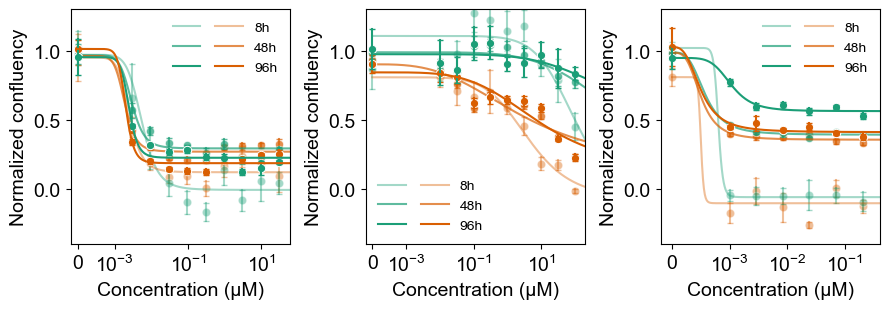

In [11]:
colors = plt.cm.Dark2.colors

# cpds = ["PTX", "DTX", "Colchicine", "CA4", "VB", "Alisertib", "Topotecan", "Ispinesib"]
cpds = ["DTX", "Alisertib", "Ispinesib"] # , "Topotecan"]
_, ax = plt.subplots(1, len(cpds), figsize=(9, 3.2))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
if len(cpds) == 1:
    ax = np.array([ax])
line_props = {
    "linestyle": "",
    "marker": "o",
    "markersize": 6,
    "err_style": "bars",
    "errorbar": "se",
    "err_kws": {"capsize": 2},
}
p0_arr = np.array(
    [
        [0, 1, 1, 2],
        [0, 0.8, 6, 1],
        [0, 1, 0.5, 2],
    ]
)
# p0_arr = np.array(
#     [
#         [0, 1, 1, 2],
#         [0, 1, 1, 2],
#         [0, 1, 2, 3],
#         [0, 1, 2, 3],
#         [0, 1, 2, 3],
#         [0, 0.8, 5, 1],
#         [0, 1, 3, 1],
#         [0, 1, 0.5, 2],
#     ]
# )
y = "gr"
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = ax[i]
    for j, t_ref in enumerate([8, 48, 96]):
        alpha = [0.4, 0.7, 1][j]
        plot_gr_curves(
            cpd,
            data,
            t_ref=t_ref,
            ax=curr_ax,
            line_props=line_props,
            dose_res_y=y,
            colors=colors[1::-1],
            alpha=alpha,
        )
        curr_data = data[(data.cpd == cpd) & (data.t == t_ref)]
        curr_data = curr_data.sort_values(by=["Wash", "lgc"]).reset_index(drop=True)

        gmin_bound = curr_data[y].min()
        bounds_l = [gmin_bound, 0.5, 0.5, 0.3]
        bounds_h = [np.inf] * 4
        bounds_h[2] = 7 if cpd == "Alisertib" else 3
        bounds_h[3] = 20

        gmin_guess = curr_data[y].min()
        gmax_guess = curr_data[y].max()
        p0 = [gmin_guess, gmax_guess, p0_arr[i][2], p0_arr[i][3]]
        params_1 = curve_fit(
            dose_response_curve,
            curr_data[np.logical_not(curr_data.Wash)].lgc.values,
            curr_data[np.logical_not(curr_data.Wash)][y].values,
            p0=p0,
            method="dogbox",
            bounds=[bounds_l, bounds_h],
        )[0]
        gmin, gmax = params_1[:2]

        p0_2 = deepcopy(params_1)
        if cpd == "Alisertib":
            p0_2[2] = 30
        params_2 = curve_fit(
            dose_response_curve,
            curr_data[curr_data.Wash].lgc.values,
            curr_data[curr_data.Wash][y].values,
            p0=p0_2,
            method="dogbox",
            bounds=[
                [gmin_guess, 0.5, params_1[2], max(0.3, params_1[3])],
                [np.inf, np.inf, np.inf, params_1[3] + 3],
            ],
        )[0]
        if cpd == "Alisertib":
            print(params_1, params_2)
        x = np.linspace(0, 8, 1000)
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_2),
            color=colors[0],
            alpha=alpha,
            label=" ",
        )
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_1),
            color=colors[1],
            alpha=alpha,
            label=f"{t_ref}h",
        )
        curr_ax.set_ylim([-0.4, 1.3])
        curr_ax.set_xlim([-0.2, curr_data.lgc.max() + 0.3])
        curr_ax.set_xlabel("")
        curr_ax.set_ylabel("")
        xticks = range(4) if cpd == "Ispinesib" else [0, 1, 3, 5]
        xticklabels = (
            [0, r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
            if cpd == "Ispinesib"
            else [0, r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
        )
        curr_ax.set_xticks(xticks)
        curr_ax.set_xticklabels(xticklabels)
        curr_ax.set_xlabel("Concentration (μM)")
        curr_ax.set_ylabel("Normalized confluency")
        # if j == 0:
        #     ax[i].set_title(cpd, fontsize=14, fontweight="bold")
    handles, labels = curr_ax.get_legend_handles_labels()
    order = [0, 2, 4, 1, 3, 5]
    curr_ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        ncols=2,
        columnspacing=0.0,
        frameon=False,
    )
# ax[0].text(2.5, 0.90, "Wash", color=colors[0], ha="center", va="top")
# ax[0].text(4.0, 0.90, "No\nWash", color=colors[1], ha="center", va="top")
# ax[1].text(0.8, 0.01, "Wash", color=colors[0], ha="center", va="bottom")
# ax[1].text(2.2, 0.01, "No\nWash", color=colors[1], ha="center", va="bottom")
# ax[2].text(1.5, 0.90, "Wash", color=colors[0], ha="center", va="top")
# ax[2].text(2.5, 0.90, "No\nWash", color=colors[1], ha="center", va="top")
save_fig("fig5-gr-dose-response", fmt="png", dpi=300)

100%|██████████████████████████████████████████████| 6/6 [00:00<00:00, 10.56it/s]


Saving figure figEx7-gr-dose-response


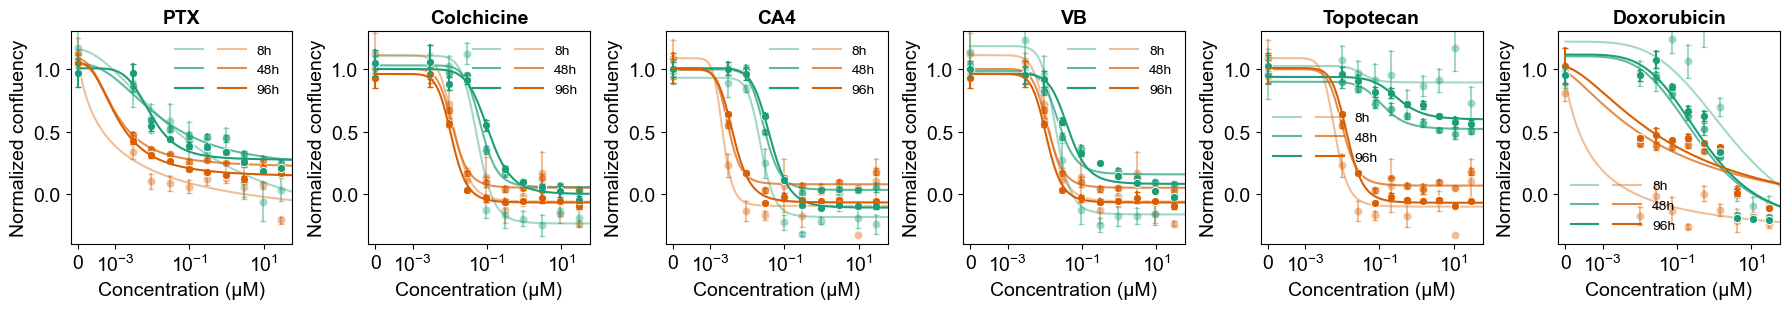

In [13]:
colors = plt.cm.Dark2.colors

cpds = ["PTX", "Colchicine", "CA4", "VB", "Topotecan", "Doxorubicin"]
# cpds = ["DTX", "Alisertib", "Ispinesib"] # , "Topotecan"]
_, ax = plt.subplots(1, len(cpds), figsize=(len(cpds) * 3, 3.2))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
if len(cpds) == 1:
    ax = np.array([ax])
line_props = {
    "linestyle": "",
    "marker": "o",
    "markersize": 6,
    "err_style": "bars",
    "errorbar": "se",
    "err_kws": {"capsize": 2},
}
p0_arr = np.array(
    [
        [0, 1, 1, 2],
        [0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 1, 2, 3],
        [0, 0.8, 5, 1],
        [0, 1, 2, 1],
    ]
)
y = "gr"
for i, cpd in enumerate(tqdm(cpds)):
    curr_ax = ax[i]
    for j, t_ref in enumerate([8, 48, 96]):
        alpha = [0.4, 0.7, 1][j]
        plot_gr_curves(
            cpd,
            data,
            t_ref=t_ref,
            ax=curr_ax,
            line_props=line_props,
            dose_res_y=y,
            colors=colors[1::-1],
            alpha=alpha,
        )
        curr_data = data[(data.cpd == cpd) & (data.t == t_ref)]
        curr_data = curr_data.sort_values(by=["Wash", "lgc"]).reset_index(drop=True)

        gmin_bound = curr_data[y].min()
        bounds_l = [gmin_bound, 0.9, 0.8, 0.3]
        bounds_h = [np.inf] * 4
        bounds_h[2] = 7 if cpd == "Topotecan" else 3
        bounds_h[3] = 10

        gmin_guess = curr_data[y].min()
        gmax_guess = curr_data[y].max()
        p0 = [gmin_guess, gmax_guess, p0_arr[i][2], p0_arr[i][3]]
        params_1 = curve_fit(
            dose_response_curve,
            curr_data[np.logical_not(curr_data.Wash)].lgc.values,
            curr_data[np.logical_not(curr_data.Wash)][y].values,
            p0=p0,
            method="dogbox",
            bounds=[bounds_l, bounds_h],
        )[0]
        gmin, gmax = params_1[:2]

        p0_2 = deepcopy(params_1)
        if cpd == "Alisertib":
            p0_2[2] = 30
        params_2 = curve_fit(
            dose_response_curve,
            curr_data[curr_data.Wash].lgc.values,
            curr_data[curr_data.Wash][y].values,
            p0=p0_2,
            method="dogbox",
            bounds=[
                [gmin_guess, 0.5, params_1[2], max(0.3, params_1[3])],
                [np.inf, np.inf, np.inf, params_1[3] + 3],
            ],
        )[0]
        if cpd == "Alisertib":
            print(params_1, params_2)
        x = np.linspace(0, 8, 1000)
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_2),
            color=colors[0],
            alpha=alpha,
            label=" ",
        )
        curr_ax.plot(
            x,
            dose_response_curve(x, *params_1),
            color=colors[1],
            alpha=alpha,
            label=f"{t_ref}h",
        )
        curr_ax.set_ylim([-0.4, 1.3])
        curr_ax.set_xlim([-0.2, curr_data.lgc.max() + 0.3])
        curr_ax.set_xlabel("")
        curr_ax.set_ylabel("")
        xticks = range(4) if cpd == "Ispinesib" else [0, 1, 3, 5]
        xticklabels = (
            [0, r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"]
            if cpd == "Ispinesib"
            else [0, r"$10^{-3}$", r"$10^{-1}$", r"$10^1$"]
        )
        curr_ax.set_xticks(xticks)
        curr_ax.set_xticklabels(xticklabels)
        curr_ax.set_xlabel("Concentration (μM)")
        curr_ax.set_ylabel("Normalized confluency")
        # if j == 0:
        #     ax[i].set_title(cpd, fontsize=14, fontweight="bold")
    handles, labels = curr_ax.get_legend_handles_labels()
    order = [0, 2, 4, 1, 3, 5]
    curr_ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        ncols=2,
        columnspacing=0.0,
        frameon=False,
    )
    curr_ax.set_title(cpd, fontsize=14, fontweight="bold")
# ax[0].text(2.5, 0.90, "Wash", color=colors[0], ha="center", va="top")
# ax[0].text(4.0, 0.90, "No\nWash", color=colors[1], ha="center", va="top")
# ax[1].text(0.8, 0.01, "Wash", color=colors[0], ha="center", va="bottom")
# ax[1].text(2.2, 0.01, "No\nWash", color=colors[1], ha="center", va="bottom")
# ax[2].text(1.5, 0.90, "Wash", color=colors[0], ha="center", va="top")
# ax[2].text(2.5, 0.90, "No\nWash", color=colors[1], ha="center", va="top")
save_fig("figEx7-gr-dose-response", fmt="png", dpi=300)

# GR DRAUC

100%|███████████████████████████████████████████| 31/31 [00:00<00:00, 254.72it/s]


Saving figure figEx7-drauc


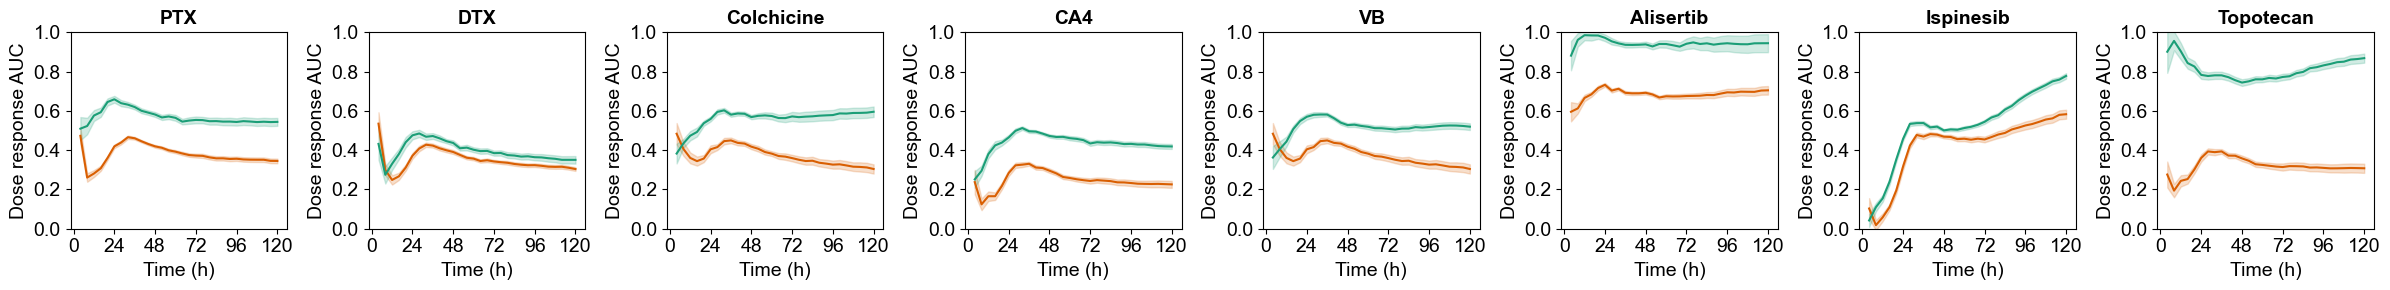

In [21]:
colors = plt.cm.Dark2.colors

# drugs = ["DTX", "Alisertib", "Ispinesib"]
drugs = ["PTX", "DTX", "Colchicine", "CA4", "VB", "Alisertib", "Ispinesib", "Topotecan"]
# drugs = ["PTX", "Colchicine", "CA4", "VB", "Topotecan", "Doxorubicin"]
y = "gr"

_, ax = plt.subplots(1, len(drugs), figsize=(len(drugs) * 3, 3))
plt.subplots_adjust(wspace=0.02)
drug_aucs = {}
for i, drug in enumerate(drugs):
    drug_data = data[data.cpd == drug][["lgc", y, "t", "Wash"]]
    params_dict = {}
    tlist = drug_data.t.unique()
    tlist = tlist[(tlist >= 0)]
    aucs = []
    for t in tqdm(tlist):
        curr_data = drug_data[drug_data.t == t]
        curr_data_std = curr_data.groupby(["Wash", "lgc"]).sem(ddof=0).reset_index()
        curr_data = curr_data.groupby(["Wash", "lgc"]).mean().reset_index()
        curr_auc = []
        for wash in [False, True]:
            df = curr_data[curr_data.Wash == wash]
            df_std = curr_data_std[curr_data_std.Wash == wash]
            lgc_minmax = df.lgc.max() - df.lgc.min()
            a = auc(df.lgc, df[y]) / lgc_minmax
            w = np.diff(df.lgc.values / lgc_minmax).tolist()
            w = np.array([0] + w + [0])
            w = 0.5 * (w[1:] + w[:-1])
            se = np.sum(((w * df_std[y].values) ** 2)) ** 0.5
            curr_auc += [a, se]
        aucs.append(curr_auc)
    aucs = np.array(aucs)
    drug_aucs[drug] = aucs
    ax[i].plot(tlist, aucs[:, 0], color=colors[1])
    ax[i].fill_between(
        tlist,
        aucs[:, 0] + aucs[:, 1],
        aucs[:, 0] - aucs[:, 1],
        alpha=0.2,
        color=colors[1],
    )
    ax[i].plot(tlist, aucs[:, 2], color=colors[0])
    ax[i].fill_between(
        tlist,
        aucs[:, 2] + aucs[:, 3],
        aucs[:, 2] - aucs[:, 3],
        alpha=0.2,
        color=colors[0],
    )
    ax[i].set_ylim(0, 1.0)
    ax[i].set_xticks([24 * i for i in range(6)])
    ax[i].set_title(drug, fontsize=14, fontweight="bold")
    # ax[i].axhline(1, ls="--", c="k")
    ax[i].set_ylabel("Dose response AUC")
    ax[i].set_xlabel("Time (h)")
# ax[1][0].set_ylabel(r"$GR_{\mathrm{max}}$")
# save_fig("fig5-drauc", fmt="png", dpi=300)
save_fig("figEx7-drauc", fmt="png", dpi=300)

# Site occupancy

In [22]:
params_df = pd.read_csv("fitting/params_df_with_bs.csv")
params_df["kd_bs"] = params_df.koff_bs / params_df.kon_bs
cpds = ["PTX", "DTX", "Colchicine", "CA4", "VB", "Alisertib", "Topotecan", "Ispinesib"]
params_df = params_df[params_df.Drug.isin(cpds)].reset_index(drop=True)
params_df = params_df.drop(
    params_df[(params_df.Drug == "Ispinesib") & (params_df.kd_bs > 0.1)].index
)

drug_to_gi50 = {}
for drug in cpds:
    gi50_8 = 10 ** (drug_gi_dict[drug][4 // 4, 2] - 4)
    gi50_48 = 10 ** (drug_gi_dict[drug][44 // 4, 2] - 4)
    gi50_96 = 10 ** (drug_gi_dict[drug][92 // 4, 2] - 4)
    drug_to_gi50[drug] = [gi50_8, gi50_48, gi50_96]
params_df["gi50_8"] = params_df.Drug.apply(lambda d: drug_to_gi50[d][0])
params_df["gi50_48"] = params_df.Drug.apply(lambda d: drug_to_gi50[d][1])
params_df["gi50_96"] = params_df.Drug.apply(lambda d: drug_to_gi50[d][2])
params_df["s_gi50_8"] = params_df.apply(
    lambda df: df.gi50_8 / (df.kd_bs + df.gi50_8), axis=1
)
params_df["s_gi50_48"] = params_df.apply(
    lambda df: df.gi50_48 / (df.kd_bs + df.gi50_48), axis=1
)
params_df["s_gi50_96"] = params_df.apply(
    lambda df: df.gi50_96 / (df.kd_bs + df.gi50_96), axis=1
)

sgi_df = params_df[["Drug", "s_gi50_8", "s_gi50_48", "s_gi50_96"]]
sgi_values = np.concatenate([params_df.s_gi50_8.values, params_df.s_gi50_48.values, params_df.s_gi50_96.values])
sgi_df = pd.concat([sgi_df] * 3).reset_index()
sgi_df["s_gi50"] = sgi_values
sgi_df["t"] = np.repeat([4, 48, 96], len(sgi_df) // 3)
sgi_df

,index,Drug,s_gi50_8,s_gi50_48,s_gi50_96,s_gi50,t
0,0,PTX,0.006609,0.007534,0.008757,0.006609,4
1,1,PTX,0.008445,0.009625,0.011183,0.008445,4
2,2,PTX,0.007106,0.008100,0.009414,0.007106,4
3,3,PTX,0.009093,0.010361,0.012037,0.009093,4
4,4,PTX,0.007665,0.008736,0.010152,0.007665,4
...,...,...,...,...,...,...,...
2476,859,Topotecan,0.027008,0.034502,0.045012,0.045012,96
2477,860,Topotecan,0.055681,0.070553,0.091010,0.091010,96
2478,861,Topotecan,0.079030,0.099482,0.127179,0.127179,96
2479,862,Topotecan,0.077318,0.097374,0.124565,0.124565,96


Saving figure fig5-sgi


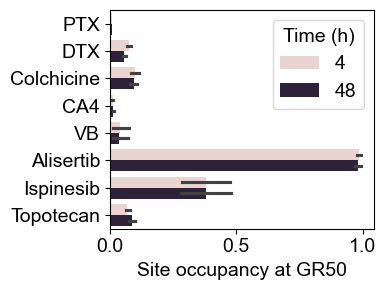

In [23]:
_, ax = plt.subplots(figsize=(4, 3))
sns.barplot(sgi_df[sgi_df.t.isin([4, 48])], y="Drug", x="s_gi50", hue="t", ax=ax, orient="h")
ax.legend(title="Timepoint (h)")
ax.set_ylabel("")
ax.set_xlabel("Site occupancy at GR50")
ax.legend(title="Time (h)", fontsize=14, title_fontsize=14)
save_fig("fig5-sgi", fmt="png", dpi=300)

# Retention time vs GR50 ratios

In [24]:
drugs = ["PTX", "DTX", "Colchicine", "CA4", "VB", "Alisertib", "Ispinesib", "Topotecan"]
# params_df = pd.read_csv("num_expt/params_df_with_bs.csv")
params_df["koff_eff_bs"] = params_df.apply(
    lambda df: df.mu_bs
    / (df.mu_bs + df.kon_bs * df.m_bs * (1 - df.s_gi50_48))
    * df.koff_bs,
    axis=1,
)
params_df["t_res_eff_bs"] = np.log(2) / params_df.koff_eff_bs
params_df = params_df[params_df.Drug.isin(drugs)].reset_index(drop=True)
params_df

,kon_bs,koff_bs,m_bs,mu_bs,k1,k2,Drug,Kd,f,kon,...,t_res_rebind_bs,t_efflux_bs,gi50_8,gi50_48,gi50_96,s_gi50_8,s_gi50_48,s_gi50_96,koff_eff_bs,t_res_eff_bs
0,284.703392,39.724379,13.186183,1.027699,0.000000,1.000000,PTX,0.139529,0.000000,311.950070,...,63.740329,0.674465,0.000928,0.001059,0.001233,0.006609,0.007534,0.008757,0.010954,63.277534
1,335.290474,36.545220,12.493606,1.025198,0.000000,1.000000,PTX,0.108996,0.000000,311.950070,...,77.499030,0.676111,0.000928,0.001059,0.001233,0.008445,0.009625,0.011183,0.009029,76.772092
2,308.509977,40.014990,12.642046,1.015400,0.000000,1.000000,PTX,0.129704,0.000000,311.950070,...,66.535287,0.682634,0.000928,0.001059,0.001233,0.007106,0.008100,0.009414,0.010500,66.013641
3,331.681283,33.556232,12.352651,1.038999,0.000000,1.000000,PTX,0.101170,0.000000,311.950070,...,81.455067,0.667130,0.000928,0.001059,0.001233,0.009093,0.010361,0.012037,0.008596,80.631730
4,326.085120,39.191336,12.275461,1.011670,0.000000,1.000000,PTX,0.120187,0.000000,311.950070,...,69.978589,0.685151,0.000928,0.001059,0.001233,0.007665,0.008736,0.010152,0.009990,69.384922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,1072.433580,309.913161,0.132034,1.003937,0.000225,0.005461,Topotecan,0.288981,0.041210,2762.397792,...,0.315454,0.690429,0.008022,0.010327,0.013621,0.027008,0.034502,0.045012,2.259233,0.306806
823,12077.216713,1643.004171,0.084983,0.966645,0.000319,0.007639,Topotecan,0.136042,0.041812,2762.397792,...,0.447940,0.717065,0.008022,0.010327,0.013621,0.055681,0.070553,0.091010,1.663189,0.416758
824,192947.127017,18036.537124,0.045060,0.961353,0.000177,0.004810,Topotecan,0.093479,0.036772,2762.397792,...,0.347550,0.721012,0.008022,0.010327,0.013621,0.079030,0.099482,0.127179,2.214430,0.313014
825,5749.826789,550.411670,0.057682,0.983138,0.000021,0.000578,Topotecan,0.095727,0.036625,2762.397792,...,0.424835,0.705035,0.008022,0.010327,0.013621,0.077318,0.097374,0.124565,1.801662,0.384727


In [25]:
params_df["auc_no_wash"] = params_df.Drug.apply(lambda d: drug_aucs[d][44 // 4, 0])
params_df["auc_no_wash_sem"] = params_df.Drug.apply(lambda d: drug_aucs[d][44 // 4, 1])
params_df["auc_wash"] = params_df.Drug.apply(lambda d: drug_aucs[d][44 // 4, 2])
params_df["auc_wash_sem"] = params_df.Drug.apply(lambda d: drug_aucs[d][44 // 4, 3])
params_df["d_auc"] = params_df.auc_wash - params_df.auc_no_wash
params_df["d_auc_sem"] = (params_df.auc_no_wash_sem ** 2 + params_df.auc_wash_sem ** 2) ** 0.5
# params_df = params_df["Drug"]

SignificanceResult(statistic=-0.6668494109751619, pvalue=1.7393733753083664e-107)
Saving figure fig5-sr-grr


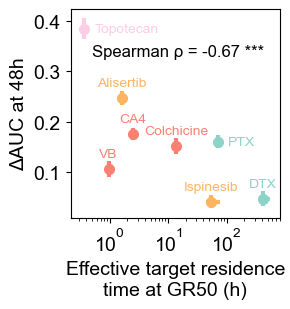

In [28]:
set3_colors = mpl.colormaps["Set3"]
colors = [
    set3_colors(0),  # 1
    set3_colors(0),  # 2
    set3_colors(3),  # 6
    set3_colors(3),  # 7
    set3_colors(3),  # 8
    set3_colors(5),  # 10
    set3_colors(5),  # 11
    set3_colors(7),  # 13
]

_, ax = plt.subplots(figsize=(3, 3.2))
for i, drug in enumerate(drugs):
    curr_df = params_df[params_df.Drug == drug]
    x = curr_df.t_res_eff_bs.median()
    xlow, xhigh = np.percentile(curr_df.t_res_eff_bs, (25, 75))
    xlow = x - xlow
    xhigh = xhigh - x
    y = curr_df.d_auc.mean()
    yerr = curr_df.d_auc_sem.mean()
    ax.errorbar(x=[x], y=[y], xerr=[[xlow], [xhigh]], yerr=[yerr], color=colors[i], marker="o", markersize=7, linewidth=3)
    if drug in ["Topotecan", "PTX"]:
        ax.text(x * 1.5, y, drug, color=colors[i], ha="left", va="center", fontsize=10)
    else:
        ax.text(x, y + 0.03, drug, color=colors[i], ha="center", va="center", fontsize=10)

rho = spearmanr(params_df.t_res_eff_bs, params_df.d_auc)
print(rho)
ax.text(0.5, 0.33, f"Spearman ρ = {rho[0]:.2f} ***", fontsize=12, ha="left")
ax.set_xlabel("Effective target residence\ntime at GR50 (h)")
ax.set_ylabel("ΔAUC at 48h")
ax.set_xscale("log")
save_fig("fig5-sr-grr", fmt="png", dpi=300)